In [1]:
import requests
import pandas as pd

BASE_URL = "https://api.openf1.org/v1"


In [2]:
def get_openf1(endpoint, **params):
    url = f"{BASE_URL}/{endpoint}"
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    return pd.DataFrame(response.json())

In [6]:
sessions = get_openf1(
    "sessions",
    year=2025,
    session_name="Race"
)

sessions.head()

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year,is_cancelled
0,9693,Race,Race,2025-03-16T04:00:00+00:00,2025-03-16T06:00:00+00:00,1254,10,Melbourne,5,AUS,Australia,Melbourne,11:00:00,2025,False
1,9998,Race,Race,2025-03-23T07:00:00+00:00,2025-03-23T09:00:00+00:00,1255,49,Shanghai,53,CHN,China,Shanghai,08:00:00,2025,False
2,10006,Race,Race,2025-04-06T05:00:00+00:00,2025-04-06T07:00:00+00:00,1256,46,Suzuka,4,JPN,Japan,Suzuka,09:00:00,2025,False
3,10014,Race,Race,2025-04-13T15:00:00+00:00,2025-04-13T17:00:00+00:00,1257,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2025,False
4,10022,Race,Race,2025-04-20T17:00:00+00:00,2025-04-20T19:00:00+00:00,1258,149,Jeddah,153,KSA,Saudi Arabia,Jeddah,03:00:00,2025,False


In [7]:
drivers = get_openf1(
    "drivers",
    session_key=9998
)

drivers.head()

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1255,9998,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://media.formula1.com/d_driver_fallback_i...,None
1,1255,9998,4,L NORRIS,Lando NORRIS,NOR,McLaren,FF8000,Lando,Norris,https://media.formula1.com/d_driver_fallback_i...,None
2,1255,9998,5,G BORTOLETO,Gabriel BORTOLETO,BOR,Kick Sauber,52E252,Gabriel,Bortoleto,https://media.formula1.com/d_driver_fallback_i...,None
3,1255,9998,6,I HADJAR,Isack HADJAR,HAD,Racing Bulls,6692FF,Isack,Hadjar,https://media.formula1.com/d_driver_fallback_i...,None
4,1255,9998,7,J DOOHAN,Jack DOOHAN,DOO,Alpine,0093CC,Jack,Doohan,https://media.formula1.com/d_driver_fallback_i...,None


In [8]:
laps = get_openf1(
    "laps",
    session_key=9998

)

laps.head()

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1255,9998,81,1,2025-03-23T07:03:38.697000+00:00,27.930,28.932,41.859,277.0,272.0,False,98.721,"[2048, 2049, 2051, 2051, 2051, 2049, 2049]","[2051, 2049, 2051, 2051, 2051, 2051]","[2051, 2051, 2049, 2049, 2049, 2049, 2049, 204...",308.0
1,1255,9998,63,1,2025-03-23T07:03:38.697000+00:00,28.492,30.020,42.264,287.0,272.0,False,100.776,"[2048, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2051, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2049, 2049, 2049, 204...",312.0
2,1255,9998,4,1,2025-03-23T07:03:38.697000+00:00,28.226,29.650,41.800,281.0,274.0,False,99.676,"[None, 2049, 2049, 2049, 2049, 2051, 2049]","[2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2051, 2049, 204...",311.0
3,1255,9998,1,1,2025-03-23T07:03:38.697000+00:00,29.811,30.530,42.425,278.0,274.0,False,102.766,"[None, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",314.0
4,1255,9998,44,1,2025-03-23T07:03:38.697000+00:00,28.860,30.143,42.199,285.0,269.0,False,101.202,"[None, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 204...",314.0


In [11]:
positions = get_openf1(
    "position",
    session_key=9998
)
positions.head()

,date,session_key,position,meeting_key,driver_number
0,2025-03-23T06:04:39.545000+00:00,9998,1,1255,81
1,2025-03-23T06:04:39.545000+00:00,9998,2,1255,63
2,2025-03-23T06:04:39.545000+00:00,9998,3,1255,4
3,2025-03-23T06:04:39.545000+00:00,9998,4,1255,1
4,2025-03-23T06:04:39.545000+00:00,9998,5,1255,44


In [14]:
intervals = get_openf1(
    "intervals",
    session_key=9998
)
intervals.head()

,date,session_key,interval,gap_to_leader,meeting_key,driver_number
0,2025-03-23T06:04:41.948000+00:00,9998,0.000,0.0,1255,81
1,2025-03-23T07:03:44.714000+00:00,9998,0.060,0.06,1255,63
2,2025-03-23T07:03:44.949000+00:00,9998,0.171,0.231,1255,4
3,2025-03-23T07:03:45.298000+00:00,9998,0.134,0.365,1255,1
4,2025-03-23T07:03:45.399000+00:00,9998,0.115,0.48,1255,44


In [17]:
stints = get_openf1(
    "stints",
    session_key=9998
)
stints.head()

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
0,1255,9998,1,23,1,20,MEDIUM,0
1,1255,9998,1,14,1,4,MEDIUM,5
2,1255,9998,1,16,1,15,MEDIUM,0
3,1255,9998,1,27,1,20,MEDIUM,0
4,1255,9998,1,18,1,36,HARD,0


In [19]:
pits = get_openf1(
    "pit",
    session_key=9998
)
pits.head()

,date,session_key,stop_duration,lap_number,lane_duration,meeting_key,driver_number,pit_duration
0,2025-03-23T07:06:04.340000+00:00,9998,3.3,1,23.385,1255,5,23.385
1,2025-03-23T07:20:44.723000+00:00,9998,3.1,10,23.138,1255,10,23.138
2,2025-03-23T07:22:19.754000+00:00,9998,2.1,11,22.519,1255,22,22.519
3,2025-03-23T07:22:21.968000+00:00,9998,2.8,11,23.114,1255,31,23.114
4,2025-03-23T07:22:27.138000+00:00,9998,2.7,11,22.793,1255,7,22.793


In [20]:
race_control = get_openf1(
    "race_control",
    session_key=9998
)

In [29]:
weather = get_openf1(
    "weather",
    session_key=9998
)
weather.head()


,date,session_key,meeting_key,track_temperature,wind_speed,rainfall,humidity,pressure,air_temperature,wind_direction
0,2025-03-23T06:05:20.723000+00:00,9998,1255,42.2,2.7,0,16.0,1011.2,27.5,230
1,2025-03-23T06:06:20.723000+00:00,9998,1255,42.2,2.6,0,16.0,1011.3,27.5,258
2,2025-03-23T06:07:20.744000+00:00,9998,1255,42.5,2.1,0,16.0,1011.3,27.6,244
3,2025-03-23T06:08:20.754000+00:00,9998,1255,42.6,2.1,0,16.0,1011.3,27.6,254
4,2025-03-23T06:09:20.776000+00:00,9998,1255,42.7,3.3,0,16.0,1011.3,27.7,248


In [30]:
telemetry = get_openf1(
    "car_data",
    session_key=9998,
    driver_number=44
)

telemetry.head()

,date,session_key,rpm,meeting_key,n_gear,driver_number,drs,throttle,speed,brake
0,2025-03-23T06:09:12.528000+00:00,9998,0,1255,0,44,0,0,0,0
1,2025-03-23T06:09:12.888000+00:00,9998,0,1255,0,44,0,0,0,0
2,2025-03-23T06:09:13.128000+00:00,9998,0,1255,0,44,0,0,0,0
3,2025-03-23T06:09:13.568000+00:00,9998,0,1255,0,44,0,0,0,0
4,2025-03-23T06:09:13.768000+00:00,9998,0,1255,0,44,0,0,0,0


In [31]:
location = get_openf1(
    "location",
    session_key=9998,
    driver_number=44
)

location.head()

,date,session_key,y,z,x,meeting_key,driver_number
0,2025-03-23T06:08:30.208000+00:00,9998,0,0,0,1255,44
1,2025-03-23T06:08:30.568000+00:00,9998,0,0,0,1255,44
2,2025-03-23T06:08:30.688000+00:00,9998,0,0,0,1255,44
3,2025-03-23T06:08:30.968000+00:00,9998,0,0,0,1255,44
4,2025-03-23T06:08:31.188000+00:00,9998,0,0,0,1255,44


In [32]:
from pathlib import Path

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

In [33]:
drivers.to_csv(RAW_DIR / "drivers.csv", index=False)
laps.to_csv(RAW_DIR / "laps.csv", index=False)
positions.to_csv(RAW_DIR / "positions.csv", index=False)
intervals.to_csv(RAW_DIR / "intervals.csv", index=False)
stints.to_csv(RAW_DIR / "stints.csv", index=False)
pits.to_csv(RAW_DIR / "pits.csv", index=False)
race_control.to_csv(RAW_DIR / "race_control.csv", index=False)
weather.to_csv(RAW_DIR / "weather.csv", index=False)

In [34]:
telemetry.to_csv(RAW_DIR / "sample_telemetry.csv", index=False)
location.to_csv(RAW_DIR / "sample_location.csv", index=False)

In [35]:
list(RAW_DIR.iterdir())

[WindowsPath('../data/raw/drivers.csv'),
 WindowsPath('../data/raw/intervals.csv'),
 WindowsPath('../data/raw/laps.csv'),
 WindowsPath('../data/raw/pits.csv'),
 WindowsPath('../data/raw/positions.csv'),
 WindowsPath('../data/raw/race_control.csv'),
 WindowsPath('../data/raw/sample_location.csv'),
 WindowsPath('../data/raw/sample_telemetry.csv'),
 WindowsPath('../data/raw/stints.csv'),
 WindowsPath('../data/raw/weather.csv')]

In [36]:
datasets = {
    "drivers": drivers,
    "laps": laps,
    "positions": positions,
    "intervals": intervals,
    "stints": stints,
    "pits": pits,
    "race_control": race_control,
    "weather": weather,
    "telemetry": telemetry,
    "location": location
}

for name, df in datasets.items():
    print(f"{name:15} rows={len(df):7} columns={len(df.columns):3}")

drivers         rows=     20 columns= 12
laps            rows=   1066 columns= 16
positions       rows=    461 columns=  5
intervals       rows=  22207 columns=  6
stints          rows=     45 columns=  8
pits            rows=     25 columns=  8
race_control    rows=     58 columns= 11
weather         rows=    154 columns= 10
telemetry       rows=  33477 columns= 10
location        rows=  34171 columns=  7


In [37]:
for name, df in datasets.items():
    print("\n", "=" * 50)
    print(name.upper())
    print("=" * 50)
    print(df.columns.tolist())


DRIVERS
['meeting_key', 'session_key', 'driver_number', 'broadcast_name', 'full_name', 'name_acronym', 'team_name', 'team_colour', 'first_name', 'last_name', 'headshot_url', 'country_code']

LAPS
['meeting_key', 'session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed']

POSITIONS
['date', 'session_key', 'position', 'meeting_key', 'driver_number']

INTERVALS
['date', 'session_key', 'interval', 'gap_to_leader', 'meeting_key', 'driver_number']

STINTS
['meeting_key', 'session_key', 'stint_number', 'driver_number', 'lap_start', 'lap_end', 'compound', 'tyre_age_at_start']

PITS
['date', 'session_key', 'stop_duration', 'lap_number', 'lane_duration', 'meeting_key', 'driver_number', 'pit_duration']

RACE_CONTROL
['meeting_key', 'session_key', 'date', 'driver_number', 'lap_number', 'category', 'flag

In [38]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head(3))


DRIVERS


,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1255,9998,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://media.formula1.com/d_driver_fallback_i...,None
1,1255,9998,4,L NORRIS,Lando NORRIS,NOR,McLaren,FF8000,Lando,Norris,https://media.formula1.com/d_driver_fallback_i...,None
2,1255,9998,5,G BORTOLETO,Gabriel BORTOLETO,BOR,Kick Sauber,52E252,Gabriel,Bortoleto,https://media.formula1.com/d_driver_fallback_i...,None



LAPS


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1255,9998,81,1,2025-03-23T07:03:38.697000+00:00,27.930,28.932,41.859,277.0,272.0,False,98.721,"[2048, 2049, 2051, 2051, 2051, 2049, 2049]","[2051, 2049, 2051, 2051, 2051, 2051]","[2051, 2051, 2049, 2049, 2049, 2049, 2049, 204...",308.0
1,1255,9998,63,1,2025-03-23T07:03:38.697000+00:00,28.492,30.020,42.264,287.0,272.0,False,100.776,"[2048, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2051, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2049, 2049, 2049, 204...",312.0
2,1255,9998,4,1,2025-03-23T07:03:38.697000+00:00,28.226,29.650,41.800,281.0,274.0,False,99.676,"[None, 2049, 2049, 2049, 2049, 2051, 2049]","[2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2051, 2049, 204...",311.0



POSITIONS


...

,date,session_key,meeting_key,track_temperature,wind_speed,rainfall,humidity,pressure,air_temperature,wind_direction
0,2025-03-23T06:05:20.723000+00:00,9998,1255,42.2,2.7,0,16.0,1011.2,27.5,230
1,2025-03-23T06:06:20.723000+00:00,9998,1255,42.2,2.6,0,16.0,1011.3,27.5,258
2,2025-03-23T06:07:20.744000+00:00,9998,1255,42.5,2.1,0,16.0,1011.3,27.6,244



TELEMETRY


,date,session_key,rpm,meeting_key,n_gear,driver_number,drs,throttle,speed,brake
0,2025-03-23T06:09:12.528000+00:00,9998,0,1255,0,44,0,0,0,0
1,2025-03-23T06:09:12.888000+00:00,9998,0,1255,0,44,0,0,0,0
2,2025-03-23T06:09:13.128000+00:00,9998,0,1255,0,44,0,0,0,0



LOCATION


,date,session_key,y,z,x,meeting_key,driver_number
0,2025-03-23T06:08:30.208000+00:00,9998,0,0,0,1255,44
1,2025-03-23T06:08:30.568000+00:00,9998,0,0,0,1255,44
2,2025-03-23T06:08:30.688000+00:00,9998,0,0,0,1255,44


In [39]:
print("PITS")
print(pits.columns.tolist())

print("\nRACE CONTROL")
print(race_control.columns.tolist())

print("\nWEATHER")
print(weather.columns.tolist())

print("\nTELEMETRY")
print(telemetry.columns.tolist())

PITS
['date', 'session_key', 'stop_duration', 'lap_number', 'lane_duration', 'meeting_key', 'driver_number', 'pit_duration']

RACE CONTROL
['meeting_key', 'session_key', 'date', 'driver_number', 'lap_number', 'category', 'flag', 'scope', 'sector', 'qualifying_phase', 'message']

WEATHER
['date', 'session_key', 'meeting_key', 'track_temperature', 'wind_speed', 'rainfall', 'humidity', 'pressure', 'air_temperature', 'wind_direction']

TELEMETRY
['date', 'session_key', 'rpm', 'meeting_key', 'n_gear', 'driver_number', 'drs', 'throttle', 'speed', 'brake']


In [40]:
for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name.upper())
    print("=" * 50)

    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())


DRIVERS
Shape: (20, 12)

Missing values:
meeting_key        0
session_key        0
driver_number      0
broadcast_name     0
full_name          0
name_acronym       0
team_name          0
team_colour        0
first_name         0
last_name          0
headshot_url       0
country_code      20
dtype: int64

LAPS
Shape: (1066, 16)

Missing values:
meeting_key            0
session_key            0
driver_number          0
lap_number             0
date_start             0
duration_sector_1      4
duration_sector_2      1
duration_sector_3      1
i1_speed             226
i2_speed               1
is_pit_out_lap         0
lap_duration           1
segments_sector_1      1
segments_sector_2      1
segments_sector_3      1
st_speed               1
dtype: int64

POSITIONS
Shape: (461, 5)

Missing values:
date             0
session_key      0
position         0
meeting_key      0
driver_number    0
dtype: int64

INTERVALS
Shape: (22207, 6)

Missing values:
date               0
session_key        0

In [44]:
print("Hamilton laps:", len(laps[laps["driver_number"] == 44]))
print("Hamilton positions:", len(positions[positions["driver_number"] == 44]))
print("Hamilton intervals:", len(intervals[intervals["driver_number"] == 44]))
print("Hamilton stints:", len(stints[stints["driver_number"] == 44]))
print("Hamilton pits:", len(pits[pits["driver_number"] == 44]))
print("Hamilton telemetry:", len(telemetry))
print("Hamilton location:", len(location))

Hamilton laps: 56
Hamilton positions: 16
Hamilton intervals: 1230
Hamilton stints: 3
Hamilton pits: 2
Hamilton telemetry: 33477
Hamilton location: 34171


In [46]:
for name, df in datasets.items():
    try:
        duplicate_count = df.duplicated().sum()
    except TypeError:
        duplicate_count = df.astype(str).duplicated().sum()

    print(
        f"{name:15} | "
        f"Rows: {len(df):7} | "
        f"Duplicates: {duplicate_count:5}"
    )

drivers         | Rows:      20 | Duplicates:     0
laps            | Rows:    1066 | Duplicates:     0
positions       | Rows:     461 | Duplicates:     0
intervals       | Rows:   22207 | Duplicates:     0
stints          | Rows:      45 | Duplicates:     0
pits            | Rows:      25 | Duplicates:     0
race_control    | Rows:      58 | Duplicates:     0
weather         | Rows:     154 | Duplicates:     0
telemetry       | Rows:   33477 | Duplicates:     0
location        | Rows:   34171 | Duplicates:     0


In [48]:
ham_laps = laps[laps["driver_number"] == 44].copy()
ham_positions = positions[positions["driver_number"] == 44].copy()
ham_intervals = intervals[intervals["driver_number"] == 44].copy()
ham_stints = stints[stints["driver_number"] == 44].copy()
ham_pits = pits[pits["driver_number"] == 44].copy()

In [49]:
ham_positions = ham_positions.sort_values("date")
ham_intervals = ham_intervals.sort_values("date")

telemetry = telemetry.sort_values("date")
location = location.sort_values("date")
race_control = race_control.sort_values("date")
weather = weather.sort_values("date")

In [50]:
print("Hamilton positions:", len(ham_positions))
print("Hamilton intervals:", len(ham_intervals))

display(ham_positions.head())

Hamilton positions: 16
Hamilton intervals: 1230


,date,session_key,position,meeting_key,driver_number
4,2025-03-23T06:04:39.545000+00:00,9998,5,1255,44
33,2025-03-23T07:03:54.350000+00:00,9998,4,1255,44
177,2025-03-23T07:25:00.929000+00:00,9998,5,1255,44
180,2025-03-23T07:25:17.181000+00:00,9998,6,1255,44
183,2025-03-23T07:25:19.954000+00:00,9998,7,1255,44


In [51]:
ham_positions = ham_positions.sort_values("date")
ham_intervals = ham_intervals.sort_values("date")
telemetry = telemetry.sort_values("date")
location = location.sort_values("date")
race_control = race_control.sort_values("date")
weather = weather.sort_values("date")

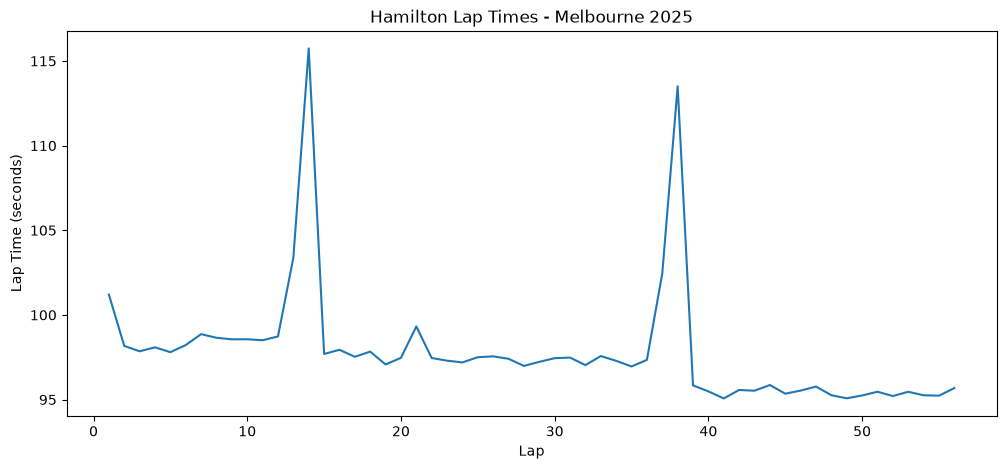

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    ham_laps["lap_number"],
    ham_laps["lap_duration"]
)

plt.xlabel("Lap")
plt.ylabel("Lap Time (seconds)")
plt.title("Hamilton Lap Times - Melbourne 2025")

plt.show()

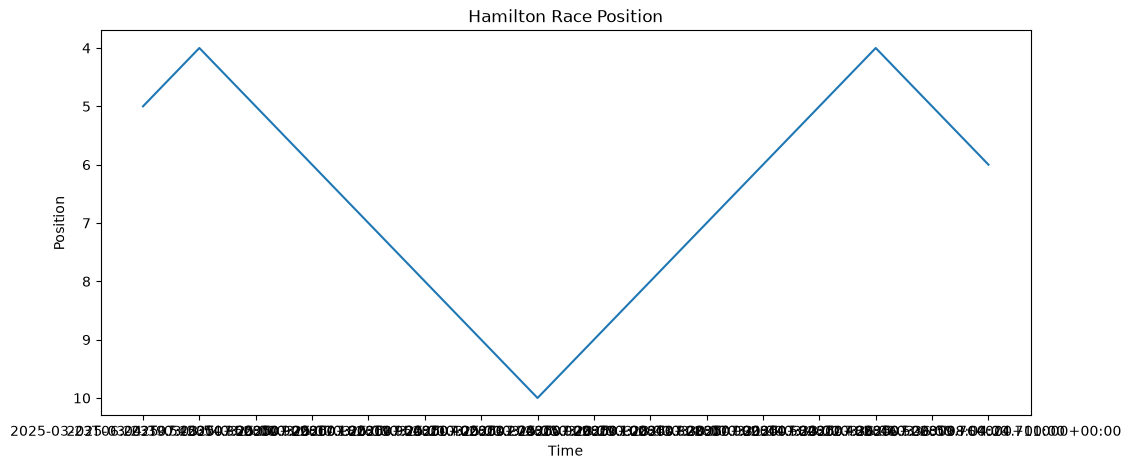

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(
    ham_positions["date"],
    ham_positions["position"]
)

plt.gca().invert_yaxis()

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Hamilton Race Position")

plt.show()

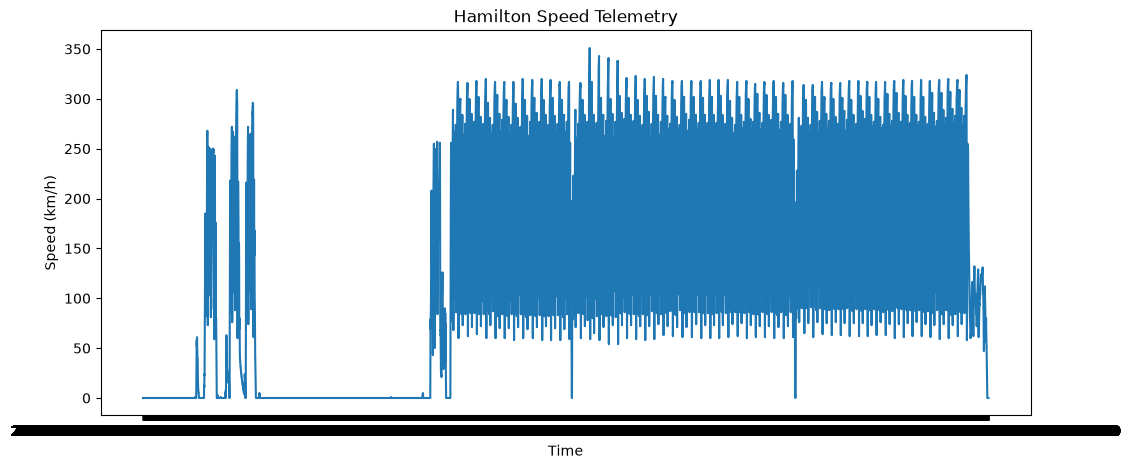

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(
    telemetry["date"],
    telemetry["speed"]
)

plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.title("Hamilton Speed Telemetry")

plt.show()

In [59]:
TARGET_LAP = 28

lap_row = ham_laps[
    ham_laps["lap_number"] == TARGET_LAP
]

display(lap_row)

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
522,1255,9998,44,28,2025-03-23T07:48:10.320000+00:00,25.855,29.276,41.858,NaN,272.0,False,96.989,"[None, 2048, 2049, 2048, 2048, 2048, 2048]","[2048, 2048, 2049, 2049, 2048, 2048]","[2048, 2048, 2049, 2048, 2048, 2048, 2048, 204...",317.0


In [60]:
stint_row = ham_stints[
    (ham_stints["lap_start"] <= TARGET_LAP) &
    (ham_stints["lap_end"] >= TARGET_LAP)
]

display(stint_row)

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
27,1255,9998,2,44,14,37,HARD,0


In [63]:
lap_time = lap_row.iloc[0]["date_start"]

print(lap_time)

2025-03-23T07:48:10.320000+00:00


In [73]:
import pandas as pd

# Convert the selected lap timestamp
lap_time = pd.to_datetime(
    lap_time,
    format="mixed",
    utc=True
)

# Convert dataset timestamps
ham_positions["date"] = pd.to_datetime(
    ham_positions["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

ham_intervals["date"] = pd.to_datetime(
    ham_intervals["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

telemetry["date"] = pd.to_datetime(
    telemetry["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

location["date"] = pd.to_datetime(
    location["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

In [74]:
print("Lap time:", lap_time)

print("Position invalid dates:", ham_positions["date"].isna().sum())
print("Interval invalid dates:", ham_intervals["date"].isna().sum())
print("Telemetry invalid dates:", telemetry["date"].isna().sum())
print("Location invalid dates:", location["date"].isna().sum())

Lap time: 2025-03-23 07:48:10.320000+00:00
Position invalid dates: 0
Interval invalid dates: 0
Telemetry invalid dates: 0
Location invalid dates: 0


In [77]:
import pandas as pd

lap_time = pd.to_datetime(lap_time)

ham_positions["date"] = pd.to_datetime(ham_positions["date"])
ham_intervals["date"] = pd.to_datetime(ham_intervals["date"])
telemetry["date"] = pd.to_datetime(telemetry["date"])
location["date"] = pd.to_datetime(location["date"])

In [75]:
position_index = (
    ham_positions["date"] - lap_time
).abs().idxmin()

position_row = ham_positions.loc[position_index]

print(position_row)

date             2025-03-23 07:36:59.764000+00:00
session_key                                  9998
position                                        5
meeting_key                                  1255
driver_number                                  44
Name: 337, dtype: object


In [76]:
interval_index = (
    ham_intervals["date"] - lap_time
).abs().idxmin()

interval_row = ham_intervals.loc[interval_index]

print(interval_row)

date             2025-03-23 07:48:10.166000+00:00
session_key                                  9998
interval                                    3.102
gap_to_leader                              10.073
meeting_key                                  1255
driver_number                                  44
Name: 10685, dtype: object


In [68]:
ham_intervals = intervals[
    intervals["driver_number"] == 44
].copy()

In [78]:
telemetry_index = (
    telemetry["date"] - lap_time
).abs().idxmin()

telemetry_row = telemetry.loc[telemetry_index]

print(telemetry_row)

date             2025-03-23 07:48:10.146000+00:00
session_key                                  9998
rpm                                         10695
meeting_key                                  1255
n_gear                                          7
driver_number                                  44
drs                                             0
throttle                                       98
speed                                         267
brake                                           0
Name: 22154, dtype: object


In [79]:
snapshot = {
    "driver_number": 44,
    "driver": "HAM",
    "lap": TARGET_LAP,

    "lap_time": lap_row.iloc[0]["lap_duration"],

    "position": position_row["position"],

    "gap_to_leader": interval_row["gap_to_leader"],
    "interval": interval_row["interval"],

    "compound": stint_row.iloc[0]["compound"],

    "speed": telemetry_row["speed"],
    "throttle": telemetry_row["throttle"],
    "brake": telemetry_row["brake"],
    "gear": telemetry_row["n_gear"],
    "rpm": telemetry_row["rpm"],
    "drs": telemetry_row["drs"]
}

snapshot

{'driver_number': 44,
 'driver': 'HAM',
 'lap': 28,
 'lap_time': np.float64(96.989),
 'position': np.int64(5),
 'gap_to_leader': 10.073,
 'interval': np.float64(3.102),
 'compound': 'HARD',
 'speed': np.int64(267),
 'throttle': np.int64(98),
 'brake': np.int64(0),
 'gear': np.int64(7),
 'rpm': np.int64(10695),
 'drs': np.int64(0)}